In [ ]:
# Green Skill Assignment
# Dataset : OWID Energy Data
# ==========================================================

# ==========================================================
# Import Libraries
# ==========================================================

# Definition:
# Libraries provide pre-written functions for data analysis,
# visualization and machine learning.

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# Import Dataset

df = pd.read_csv("owid-energy-data.csv")

print("Dataset Imported Successfully!")

Dataset Imported Successfully!


In [3]:
print(df.head())

         country  year iso_code  population  gdp  biofuel_cons_change_pct  \
0  ASEAN (Ember)  2000      NaN         NaN  NaN                      NaN   
1  ASEAN (Ember)  2001      NaN         NaN  NaN                      NaN   
2  ASEAN (Ember)  2002      NaN         NaN  NaN                      NaN   
3  ASEAN (Ember)  2003      NaN         NaN  NaN                      NaN   
4  ASEAN (Ember)  2004      NaN         NaN  NaN                      NaN   

   biofuel_cons_change_twh  biofuel_cons_per_capita  biofuel_consumption  \
0                      NaN                      NaN                  NaN   
1                      NaN                      NaN                  NaN   
2                      NaN                      NaN                  NaN   
3                      NaN                      NaN                  NaN   
4                      NaN                      NaN                  NaN   

   biofuel_elec_per_capita  ...  solar_share_elec  solar_share_energy  \
0      

In [4]:
print(df.tail())

        country  year iso_code  population           gdp  \
23372  Zimbabwe  2020      ZWE  15526887.0  2.317871e+10   
23373  Zimbabwe  2021      ZWE  15797220.0  2.514009e+10   
23374  Zimbabwe  2022      ZWE  16069061.0  2.590159e+10   
23375  Zimbabwe  2023      ZWE  16340829.0           NaN   
23376  Zimbabwe  2024      ZWE  16634366.0           NaN   

       biofuel_cons_change_pct  biofuel_cons_change_twh  \
23372                      NaN                      0.0   
23373                      NaN                      0.0   
23374                      NaN                      0.0   
23375                      NaN                      0.0   
23376                      NaN                      0.0   

       biofuel_cons_per_capita  biofuel_consumption  biofuel_elec_per_capita  \
23372                      0.0                  0.0                    6.440   
23373                      0.0                  0.0                    6.963   
23374                      0.0              

In [5]:
print(df.shape)

(23377, 130)


In [ ]:
print(df.columns)

Index(['country', 'year', 'iso_code', 'population', 'gdp',
       'biofuel_cons_change_pct', 'biofuel_cons_change_twh',
       'biofuel_cons_per_capita', 'biofuel_consumption',
       'biofuel_elec_per_capita',
       ...
       'solar_share_elec', 'solar_share_energy', 'wind_cons_change_pct',
       'wind_cons_change_twh', 'wind_consumption', 'wind_elec_per_capita',
       'wind_electricity', 'wind_energy_per_capita', 'wind_share_elec',
       'wind_share_energy'],
      dtype='str', length=130)


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23377 entries, 0 to 23376
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), str(2)
memory usage: 23.2 MB


In [8]:
print(df.describe())

               year    population           gdp  biofuel_cons_change_pct  \
count  23377.000000  1.889400e+04  1.178000e+04              2070.000000   
mean    1976.238611  1.058587e+08  4.257565e+11                43.478804   
std       35.331092  4.720948e+08  3.507870e+12               286.672317   
min     1900.000000  1.776000e+03  1.642060e+08              -100.000000   
25%     1949.000000  1.599088e+06  1.426394e+10                -0.968000   
50%     1985.000000  6.951653e+06  4.357680e+10                 6.695500   
75%     2005.000000  2.581793e+07  1.830576e+11                23.320750   
max     2025.000000  8.231613e+09  1.301126e+14              6373.062000   

       biofuel_cons_change_twh  biofuel_cons_per_capita  biofuel_consumption  \
count              7903.000000              6338.000000          8057.000000   
mean                  1.054261                55.157113            15.092054   
std                   6.641947               180.660550            75.94252

In [9]:
# ==========================================================
# Report Understanding
# ==========================================================

print("""
Dataset Understanding

The OWID Energy Dataset contains yearly information
about energy production, electricity generation,
renewable energy, GDP, population and carbon emissions.

Each row represents one country in one year.

The dataset can be used to study energy consumption,
renewable energy growth and environmental sustainability.
""")


Dataset Understanding

The OWID Energy Dataset contains yearly information
about energy production, electricity generation,
renewable energy, GDP, population and carbon emissions.

Each row represents one country in one year.

The dataset can be used to study energy consumption,
renewable energy growth and environmental sustainability.



In [10]:

print("Missing Values in Dataset\n")

print(df.isnull().sum())

Missing Values in Dataset

country                       0
year                          0
iso_code                   6112
population                 4483
gdp                       11597
                          ...  
wind_elec_per_capita      14972
wind_electricity          13870
wind_energy_per_capita    18232
wind_share_elec           15716
wind_share_energy         16998
Length: 130, dtype: int64


In [11]:
# ==========================================================
# Handle Null Values
# ==========================================================

numeric_columns = df.select_dtypes(include=["number"]).columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].mean()
)

print("Missing Values After Handling\n")

print(df[numeric_columns].isnull().sum())

Missing Values After Handling

year                       0
population                 0
gdp                        0
biofuel_cons_change_pct    0
biofuel_cons_change_twh    0
                          ..
wind_elec_per_capita       0
wind_electricity           0
wind_energy_per_capita     0
wind_share_elec            0
wind_share_energy          0
Length: 128, dtype: int64


In [12]:
# ==========================================================
# Feature Engineering
# ==========================================================

df["Energy_per_Person"] = (
    df["primary_energy_consumption"] /
    df["population"]
)

print(df[["Energy_per_Person"]].head())

   Energy_per_Person
0            0.00004
1            0.00004
2            0.00004
3            0.00004
4            0.00004


C:\Users\jayvi\AppData\Local\Temp\ipykernel_31360\2965208423.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Energy_per_Person"] = (


In [13]:
# ==========================================================
# Label Encoding
# ==========================================================

encoder = LabelEncoder()

df["country"] = encoder.fit_transform(df["country"])

print(df["country"].head())

0    0
1    0
2    0
3    0
4    0
Name: country, dtype: int32


In [14]:
# ==========================================================
# Scaling
# ==========================================================

scaler = StandardScaler()

columns_to_scale = [
    "population",
    "gdp",
    "primary_energy_consumption"
]

df[columns_to_scale] = scaler.fit_transform(
    df[columns_to_scale]
)

print(df[columns_to_scale].head())

     population  gdp  primary_energy_consumption
0 -3.511032e-17  0.0                         0.0
1 -3.511032e-17  0.0                         0.0
2 -3.511032e-17  0.0                         0.0
3 -3.511032e-17  0.0                         0.0
4 -3.511032e-17  0.0                         0.0


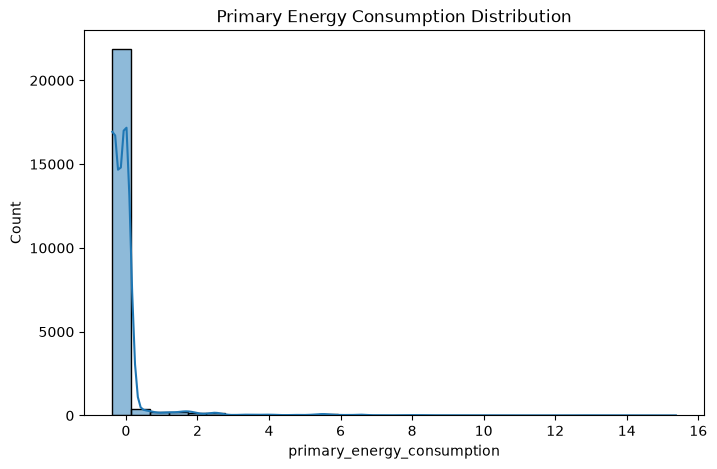

In [15]:
# ==========================================================
# Histogram
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="primary_energy_consumption",
    bins=30,
    kde=True
)

plt.title("Primary Energy Consumption Distribution")

plt.show()

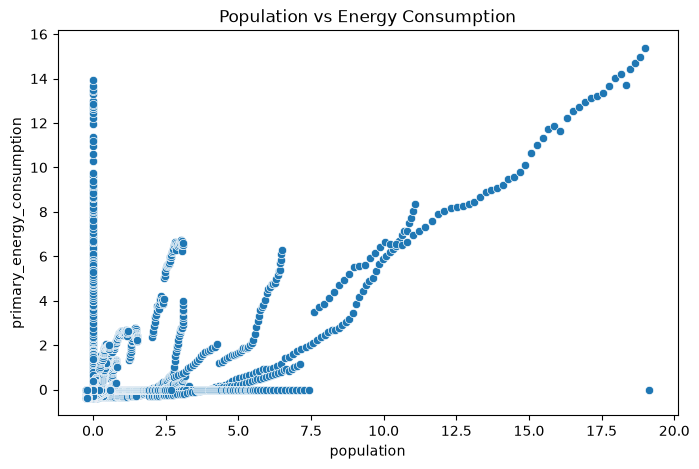

In [16]:
# ==========================================================
# Scatter Plot
# ==========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="population",
    y="primary_energy_consumption"
)

plt.title("Population vs Energy Consumption")

plt.show()

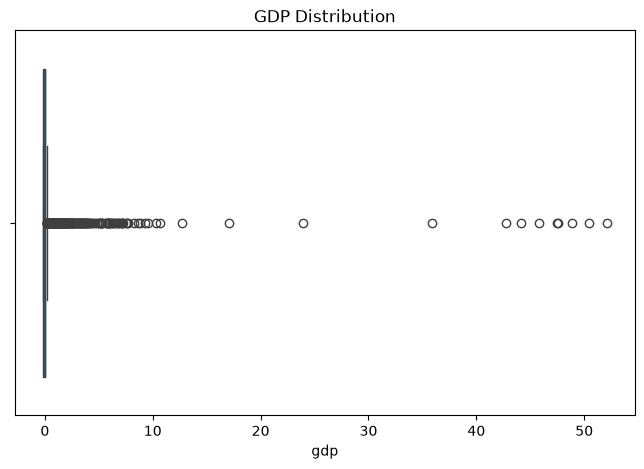

In [17]:
# ==========================================================
# Box Plot
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["gdp"]
)

plt.title("GDP Distribution")

plt.show()

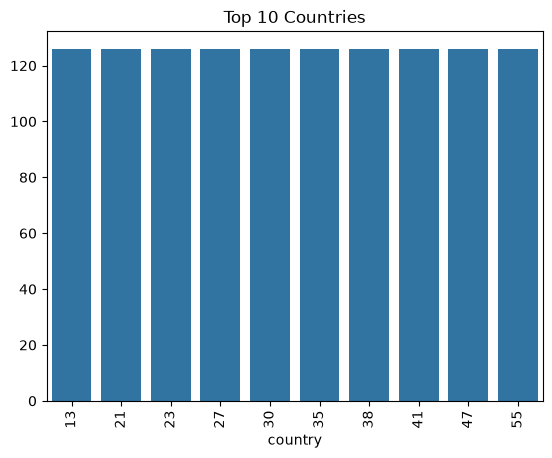

In [18]:
# ==========================================================
# Count Plot
# ==========================================================

top_countries = df["country"].value_counts().head(10)

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.title("Top 10 Countries")

plt.xticks(rotation=90)

plt.show()

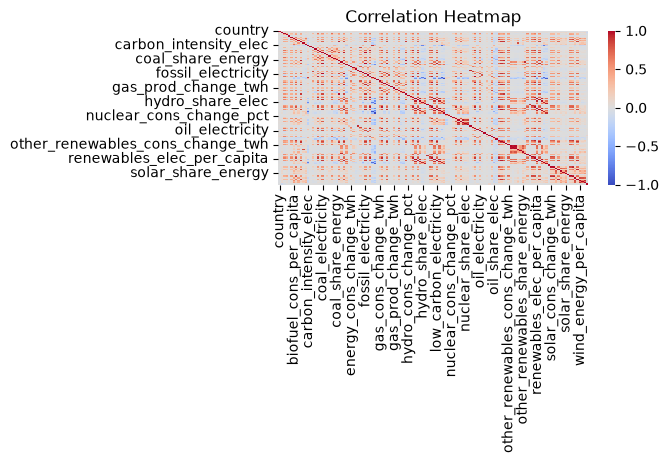

In [22]:
# ==========================================================
# Heatmap
# ==========================================================

plt.figure(figsize=(5,2))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [23]:
# ==========================================================
# Train Test Split
# ==========================================================

# Selecting Features (X) and Target (y)

X = df[[
    "population",
    "gdp",
    "renewables_consumption",
    "coal_consumption",
    "gas_consumption",
    "oil_consumption",
    "electricity_generation"
]]

y = df["primary_energy_consumption"]

# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (18701, 7)
Testing Data Shape : (4676, 7)


In [24]:
# ==========================================================
# Linear Regression
# ==========================================================

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [25]:
# ==========================================================
# Prediction
# ==========================================================

y_pred = model.predict(X_test)

print("Predicted Values")

print(y_pred[:10])

Predicted Values
[-1.40683391e-02 -3.15434113e-02 -8.30283258e-03 -6.05606107e-02
 -1.32364003e-02 -1.41086868e-02 -1.31958413e-02 -5.15217896e-01
 -1.26176309e-02 -3.88323607e-04]


In [26]:
# ==========================================================
# Evaluation
# ==========================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("R2 Score :", r2)

Mean Absolute Error : 0.19247263634173395
Mean Squared Error : 0.36097969920695944
Root Mean Squared Error : 0.6008158613143959
R2 Score : 0.6767741780413635


In [ ]:
# ==========================================================
# Error Explanation
# ==========================================================

print("""

MAE (Mean Absolute Error)

Shows the average prediction error.

Smaller MAE means better predictions.



MSE (Mean Squared Error)

Squares the errors.

Large mistakes receive more penalty.



RMSE (Root Mean Squared Error)

Represents prediction error

in the original unit.

Lower RMSE indicates better accuracy.



R² Score

Ranges from 0 to 1.

Closer to 1 means

the model explains

most of the variation.

""")

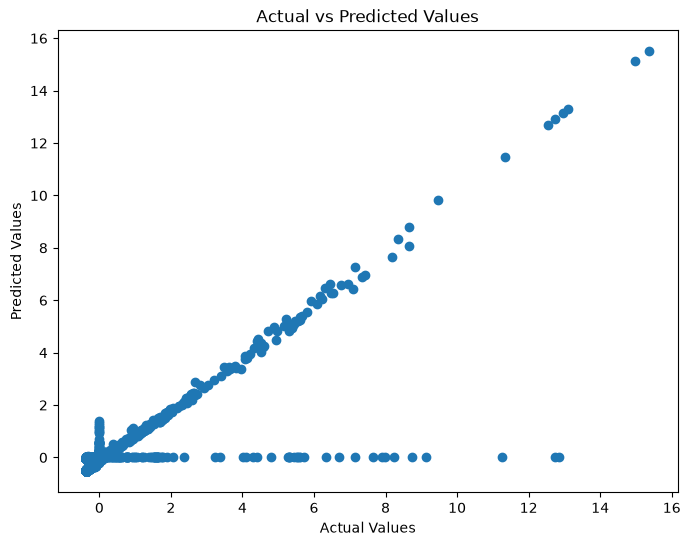

In [27]:
# ==========================================================
# Actual vs Predicted
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Values")

plt.show()

In [28]:


print("""

Insights

1. Dataset contains global energy information.

2. Missing values were replaced using mean.

3. Energy_per_Person was created using feature engineering.

4. Country names were encoded into numbers.

5. Numerical columns were scaled.

6. Seaborn graphs helped understand data visually.

7. Population and GDP positively influence energy consumption.

8. Renewable energy contributes toward sustainability.

9. Linear Regression successfully predicted
primary energy consumption.

10. R² Score tells how well the model explains the data.

""")



Insights

1. Dataset contains global energy information.

2. Missing values were replaced using mean.

3. Energy_per_Person was created using feature engineering.

4. Country names were encoded into numbers.

5. Numerical columns were scaled.

6. Seaborn graphs helped understand data visually.

7. Population and GDP positively influence energy consumption.

8. Renewable energy contributes toward sustainability.

9. Linear Regression successfully predicted
primary energy consumption.

10. R² Score tells how well the model explains the data.





Summary

✔ Imported the OWID Energy Dataset.

✔ Explored the dataset.

✔ Understood all important columns.

✔ Analyzed relationships among features.

✔ Handled missing values.

✔ Created a new feature.

✔ Applied Label Encoding.

✔ Applied Standard Scaling.

✔ Visualized the dataset using Seaborn.

✔ Split dataset into training and testing data.

✔ Built a Linear Regression model.

✔ Predicted primary energy consumption.

✔ Evaluated the model using

   MAE

   MSE

   RMSE

   R² Score

✔ Explained model errors.

✔ Generated meaningful insights.

Assignment Completed Successfully.
